Dispositivo: cuda


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Random Baseline: -20.40 +/- 0.86

===== INIZIO: Linear decay =====
Linear decay             | Step   19209/1800000 | Episodio   20 | Media ultimi 20: -20.70 | eps: 1.000 | Tempo: 0.3m
Linear decay             | Step   38933/1800000 | Episodio   40 | Media ultimi 20: -20.25 | eps: 0.977 | Tempo: 1.2m
Linear decay             | Step   58872/1800000 | Episodio   60 | Media ultimi 20: -20.45 | eps: 0.952 | Tempo: 2.0m
Linear decay             | Step   78177/1800000 | Episodio   80 | Media ultimi 20: -20.65 | eps: 0.928 | Tempo: 2.9m
Linear decay             | Step   98201/1800000 | Episodio  100 | Media ultimi 20: -20.20 | eps: 0.903 | Tempo: 3.8m
Linear decay             | Step  120197/1800000 | Episodio  120 | Media ultimi 20: -20.00 | eps: 0.876 | Tempo: 4.7m
Linear decay             | Step  142226/1800000 | Episodio  140 | Media ultimi 20: -20.10 | eps: 0.849 | Tempo: 5.7m
Linear decay             | Step  164248/1800000 | Episodio  160 | Media ultimi 20: -20.20 | eps: 0.821 | Tempo: 6.

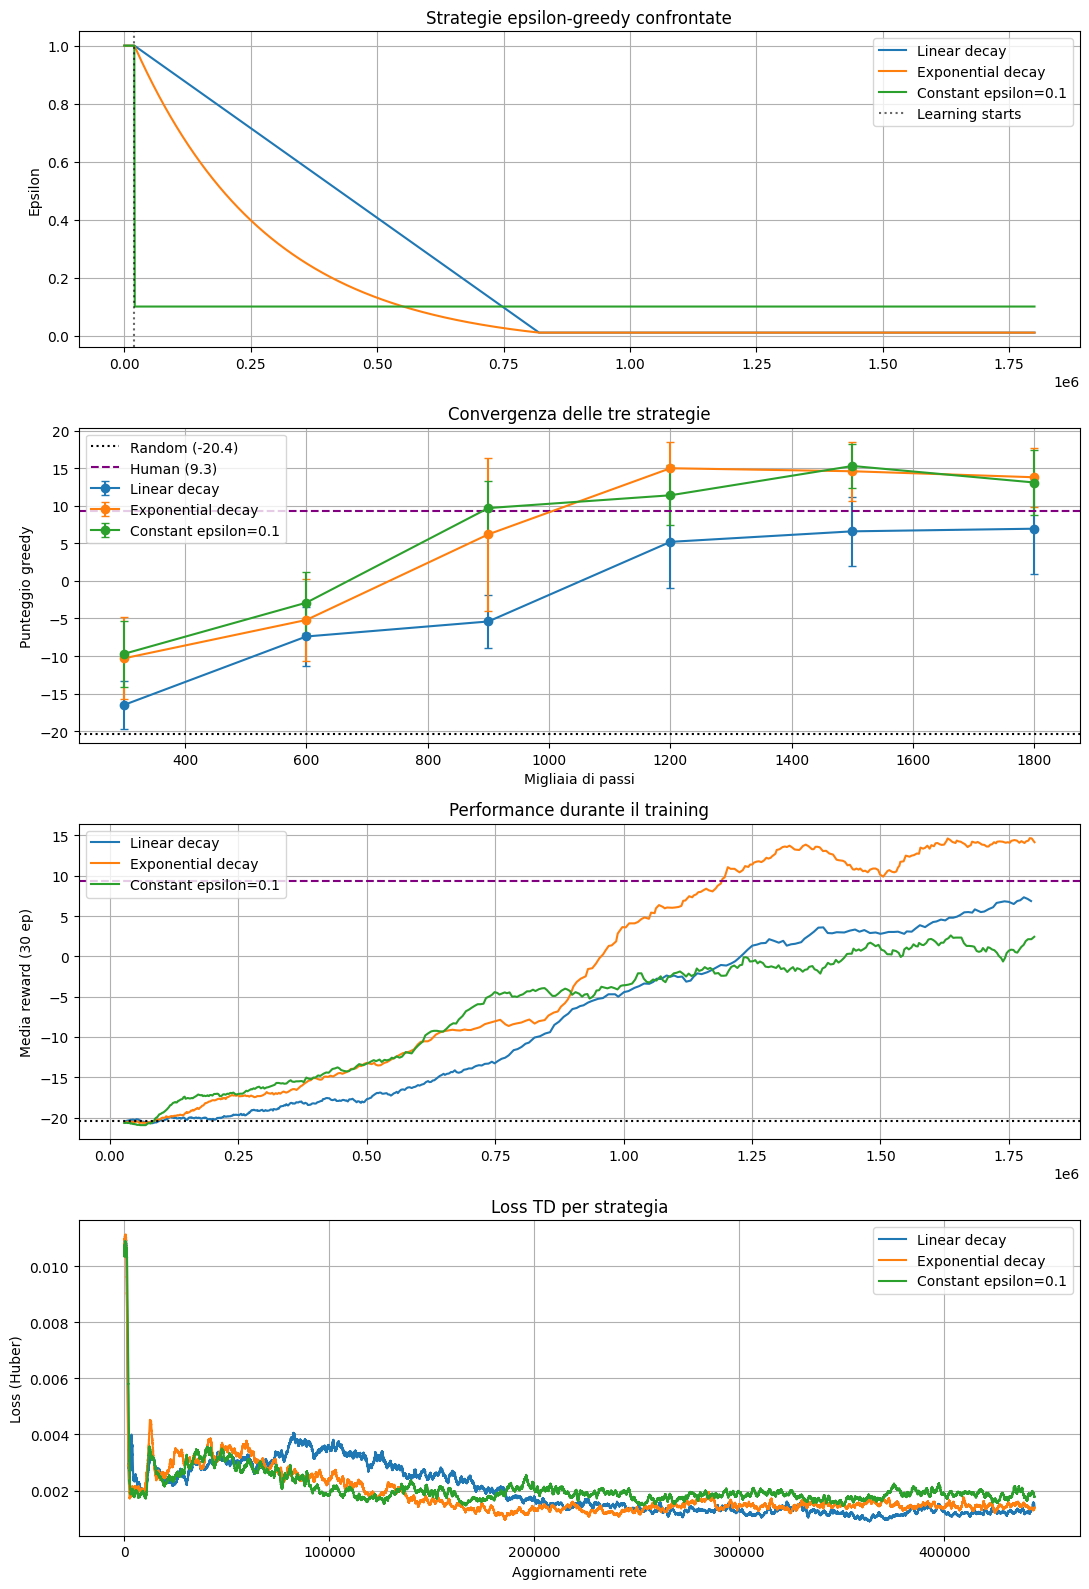

In [1]:
!pip install -q "gymnasium[atari]==1.2.0" "ale-py==0.11.2"

import random
import collections
import gc
import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import torch
import torch.nn as nn
import torch.optim as optim


SEED = 3


def reset_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


reset_seeds(SEED)
gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device, flush=True)


class FireResetEnv(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, term, trunc, info = self.env.step(1)
        if term or trunc:
            obs, info = self.env.reset(**kwargs)
        return obs, info


class PongThreeActions(gym.ActionWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.action_mapping = [0, 2, 3]
        self.action_space = gym.spaces.Discrete(3)

    def action(self, act):
        return self.action_mapping[int(act)]


def make_env():
    env = gym.make("ALE/Pong-v5", frameskip=1)
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,
    )
    env = FireResetEnv(env)
    env = PongThreeActions(env)
    env = FrameStackObservation(env, stack_size=4)
    return env


class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.net(x / 255.0)


class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, terminated):
        self.buffer.append(
            (
                np.array(state, dtype=np.uint8),
                action,
                reward,
                np.array(next_state, dtype=np.uint8),
                terminated,
            )
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, terminated = zip(*batch)
        return (
            torch.tensor(
                np.array(states), dtype=torch.uint8, device=device
            ).float(),
            torch.tensor(actions, dtype=torch.int64, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(
                np.array(next_states), dtype=torch.uint8, device=device
            ).float(),
            torch.tensor(terminated, dtype=torch.float32, device=device),
        )

    def clear(self):
        self.buffer.clear()

    def __len__(self):
        return len(self.buffer)


def evaluate(eval_env, model=None, episodes=20, base_seed=1000):
    scores = []
    for episode in range(episodes):
        episode_seed = base_seed + episode
        state, _ = eval_env.reset(seed=episode_seed)
        if model is None:
            eval_env.action_space.seed(episode_seed)

        done = False
        total_reward = 0.0
        while not done:
            if model is None:
                action = eval_env.action_space.sample()
            else:
                state_t = torch.tensor(
                    np.array(state), dtype=torch.uint8, device=device
                ).float().unsqueeze(0)
                with torch.no_grad():
                    action = model(state_t).argmax(dim=1).item()

            state, reward, term, trunc, _ = eval_env.step(action)
            done = term or trunc
            total_reward += reward

        scores.append(total_reward)

    return float(np.mean(scores)), float(np.std(scores))




BUFFER_CAPACITY = 100000
TOTAL_STEPS = 1800000
LEARNING_STARTS = 20000
TRAIN_FREQ = 4
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-4
TARGET_UPDATE = 2000
CHECKPOINTS = [
    300_000,
    600_000,
    900_000,
    1_200_000,
    1_500_000,
    1_800_000,
]
EVAL_EPISODES = 10
FINAL_EVAL_EPISODES = 20
HUMAN_BENCHMARK = 9.3

EPS_START = 1.0
EPS_END = 0.01
DECAY_STEPS = 800000
CONSTANT_EPS = 0.10
EXPONENTIAL_K = 3.0

STRATEGIES = ["linear", "exponential", "constant"]
STRATEGY_LABELS = {
    "linear": "Linear decay",
    "exponential": "Exponential decay",
    "constant": f"Constant epsilon={CONSTANT_EPS}",
}
STRATEGY_COLORS = {
    "linear": "tab:blue",
    "exponential": "tab:orange",
    "constant": "tab:green",
}

assert TOTAL_STEPS in CHECKPOINTS


def epsilon_value(strategy, step):
    """Restituisce epsilon; i primi LEARNING_STARTS passi sono casuali."""
    if step <= LEARNING_STARTS:
        return EPS_START

    schedule_step = step - LEARNING_STARTS

    if strategy == "constant":
        return CONSTANT_EPS

    progress = min(schedule_step / DECAY_STEPS, 1.0)

    if strategy == "linear":
        return EPS_START + progress * (EPS_END - EPS_START)

    if strategy == "exponential":


        exp_end = np.exp(-EXPONENTIAL_K)
        normalized = (
            np.exp(-EXPONENTIAL_K * progress) - exp_end
        ) / (1.0 - exp_end)
        return EPS_END + (EPS_START - EPS_END) * normalized

    raise ValueError(f"Strategia sconosciuta: {strategy}")


def train_strategy(strategy):

    reset_seeds(SEED)

    env = make_env()
    eval_env = make_env()
    env.action_space.seed(SEED)
    eval_env.action_space.seed(SEED + 1)

    n_actions = env.action_space.n
    policy_net = DQN(n_actions).to(device)
    target_net = DQN(n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    loss_fn = nn.SmoothL1Loss()
    replay_buffer = ReplayBuffer(capacity=BUFFER_CAPACITY)

    state, _ = env.reset(seed=SEED)
    episode_reward = 0.0
    rewards_history = []
    step_history = []
    loss_history = []
    checkpoint_results = {}

    policy_net.train()
    start_time = time.time()
    label = STRATEGY_LABELS[strategy]
    print(f"\n===== INIZIO: {label} =====", flush=True)

    for step in range(1, TOTAL_STEPS + 1):
        epsilon = epsilon_value(strategy, step)

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_t = torch.tensor(
                np.array(state), dtype=torch.uint8, device=device
            ).float().unsqueeze(0)
            with torch.no_grad():
                action = policy_net(state_t).argmax(dim=1).item()

        next_state, reward, term, trunc, _ = env.step(action)
        replay_buffer.push(state, action, reward, next_state, term)
        state = next_state
        episode_reward += reward

        if term or trunc:
            rewards_history.append(episode_reward)
            step_history.append(step)

            if len(rewards_history) % 20 == 0:
                avg_recent = np.mean(rewards_history[-20:])
                elapsed = (time.time() - start_time) / 60.0
                print(
                    f"{label:24s} | Step {step:7d}/{TOTAL_STEPS} | "
                    f"Episodio {len(rewards_history):4d} | "
                    f"Media ultimi 20: {avg_recent:6.2f} | "
                    f"eps: {epsilon:.3f} | Tempo: {elapsed:.1f}m",
                    flush=True,
                )

            state, _ = env.reset()
            episode_reward = 0.0



        if step > LEARNING_STARTS and step % TRAIN_FREQ == 0:
            b_s, b_a, b_r, b_ns, b_terminated = replay_buffer.sample(
                BATCH_SIZE
            )

            with torch.no_grad():
                max_next_q = target_net(b_ns).max(dim=1).values
                target_q = (
                    b_r
                    + (1.0 - b_terminated) * GAMMA * max_next_q
                )

            current_q = policy_net(b_s).gather(
                1, b_a.unsqueeze(1)
            ).squeeze(1)
            loss = loss_fn(current_q, target_q)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()
            loss_history.append(loss.item())

        if step % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if step % 100000 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if step in CHECKPOINTS:
            episodes = (
                FINAL_EVAL_EPISODES
                if step == TOTAL_STEPS
                else EVAL_EPISODES
            )
            policy_net.eval()
            mean_score, std_score = evaluate(
                eval_env,
                model=policy_net,
                episodes=episodes,
                base_seed=1000,
            )
            policy_net.train()
            checkpoint_results[step] = {
                "mean": mean_score,
                "std": std_score,
                "episodes": episodes,
            }
            print(
                f"\n--- {label} | Checkpoint {step}: "
                f"{mean_score:.2f} +/- {std_score:.2f} "
                f"({episodes} episodi) ---\n",
                flush=True,
            )

    elapsed_minutes = (time.time() - start_time) / 60.0



    torch.save(
        {
            "strategy": strategy,
            "step": TOTAL_STEPS,
            "policy_state_dict": policy_net.state_dict(),
            "target_state_dict": target_net.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epsilon_final": epsilon_value(strategy, TOTAL_STEPS),
        },
        f"dqn_pong_epsilon_{strategy}_{TOTAL_STEPS}.pth",
    )

    result = {
        "strategy": strategy,
        "label": label,
        "steps": step_history,
        "rewards": rewards_history,
        "losses": loss_history,
        "checkpoints": checkpoint_results,
        "elapsed_minutes": elapsed_minutes,
    }

    env.close()
    eval_env.close()
    replay_buffer.clear()
    del replay_buffer, policy_net, target_net, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        f"===== FINE: {label} | {elapsed_minutes:.1f} minuti =====",
        flush=True,
    )
    return result



baseline_env = make_env()
rand_mean, rand_std = evaluate(
    baseline_env, model=None, episodes=20, base_seed=1000
)
baseline_env.close()
print(
    f"Random Baseline: {rand_mean:.2f} +/- {rand_std:.2f}",
    flush=True,
)




experiment_start = time.time()
results = {}
for strategy in STRATEGIES:
    results[strategy] = train_strategy(strategy)

total_elapsed_minutes = (time.time() - experiment_start) / 60.0



print("\n===== RISULTATI EPSILON-GREEDY ABLATION =====", flush=True)
print(
    f"Random: {rand_mean:.2f} +/- {rand_std:.2f} | "
    f"Human benchmark: {HUMAN_BENCHMARK:.2f}",
    flush=True,
)

summary = {}
for strategy in STRATEGIES:
    result = results[strategy]
    checkpoint_steps = sorted(result["checkpoints"])
    checkpoint_means = [
        result["checkpoints"][step]["mean"] for step in checkpoint_steps
    ]



    auc_steps = np.array([0] + checkpoint_steps, dtype=np.float64)
    auc_scores = np.array([rand_mean] + checkpoint_means, dtype=np.float64)
    normalized_auc = float(
        np.trapezoid(auc_scores, auc_steps) / TOTAL_STEPS
    )

    first_nonnegative = next(
        (
            step
            for step, score in zip(checkpoint_steps, checkpoint_means)
            if score >= 0.0
        ),
        None,
    )
    first_human = next(
        (
            step
            for step, score in zip(checkpoint_steps, checkpoint_means)
            if score >= HUMAN_BENCHMARK
        ),
        None,
    )
    final = result["checkpoints"][TOTAL_STEPS]

    epsilon_grid = [
        epsilon_value(strategy, int(step))
        for step in np.linspace(1, TOTAL_STEPS, 2001)
    ]
    mean_epsilon = float(np.mean(epsilon_grid))

    summary[strategy] = {
        "final_mean": final["mean"],
        "final_std": final["std"],
        "normalized_auc": normalized_auc,
        "first_nonnegative": first_nonnegative,
        "first_human": first_human,
        "mean_epsilon": mean_epsilon,
    }

    print(
        f"{result['label']:24s} | "
        f"finale {final['mean']:6.2f} +/- {final['std']:.2f} | "
        f"AUC media {normalized_auc:6.2f} | "
        f"eps media {mean_epsilon:.3f} | "
        f"primo >= 0: {first_nonnegative} | "
        f"primo >= human: {first_human}",
        flush=True,
    )

print(
    f"Tempo complessivo: {total_elapsed_minutes:.1f} minuti",
    flush=True,
)



fig, axes = plt.subplots(4, 1, figsize=(11, 16))
ax1, ax2, ax3, ax4 = axes


schedule_steps = np.linspace(1, TOTAL_STEPS, 2000).astype(int)
for strategy in STRATEGIES:
    schedule_values = [
        epsilon_value(strategy, step) for step in schedule_steps
    ]
    ax1.plot(
        schedule_steps,
        schedule_values,
        color=STRATEGY_COLORS[strategy],
        label=STRATEGY_LABELS[strategy],
    )
ax1.axvline(
    LEARNING_STARTS,
    color="black",
    linestyle=":",
    alpha=0.6,
    label="Learning starts",
)
ax1.set_ylabel("Epsilon")
ax1.set_title("Strategie epsilon-greedy confrontate")
ax1.legend()
ax1.grid(True)


for strategy in STRATEGIES:
    checkpoints = results[strategy]["checkpoints"]
    x = np.array(sorted(checkpoints)) / 1000.0
    means = [checkpoints[step]["mean"] for step in sorted(checkpoints)]
    stds = [checkpoints[step]["std"] for step in sorted(checkpoints)]
    ax2.errorbar(
        x,
        means,
        yerr=stds,
        marker="o",
        capsize=3,
        color=STRATEGY_COLORS[strategy],
        label=STRATEGY_LABELS[strategy],
    )
ax2.axhline(
    rand_mean,
    color="black",
    linestyle=":",
    label=f"Random ({rand_mean:.1f})",
)
ax2.axhline(
    HUMAN_BENCHMARK,
    color="purple",
    linestyle="--",
    label=f"Human ({HUMAN_BENCHMARK})",
)
ax2.set_xlabel("Migliaia di passi")
ax2.set_ylabel("Punteggio greedy")
ax2.set_title("Convergenza delle tre strategie")
ax2.legend(loc="upper left")
ax2.grid(True)


rolling_window = 30
for strategy in STRATEGIES:
    step_history = results[strategy]["steps"]
    rewards = results[strategy]["rewards"]
    if len(rewards) >= rolling_window:
        rolling = np.convolve(
            rewards,
            np.ones(rolling_window) / rolling_window,
            mode="valid",
        )
        ax3.plot(
            step_history[rolling_window - 1 :],
            rolling,
            color=STRATEGY_COLORS[strategy],
            label=STRATEGY_LABELS[strategy],
        )
ax3.axhline(rand_mean, color="black", linestyle=":")
ax3.axhline(HUMAN_BENCHMARK, color="purple", linestyle="--")
ax3.set_ylabel("Media reward (30 ep)")
ax3.set_title("Performance durante il training")
ax3.legend(loc="upper left")
ax3.grid(True)


loss_window = 1000
for strategy in STRATEGIES:
    losses = results[strategy]["losses"]
    if len(losses) >= loss_window:
        smooth_loss = np.convolve(
            losses,
            np.ones(loss_window) / loss_window,
            mode="valid",
        )
        ax4.plot(
            smooth_loss,
            color=STRATEGY_COLORS[strategy],
            label=STRATEGY_LABELS[strategy],
        )
ax4.set_xlabel("Aggiornamenti rete")
ax4.set_ylabel("Loss (Huber)")
ax4.set_title("Loss TD per strategia")
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.savefig("epsilon_greedy_ablation.png", dpi=150)
plt.show()
